# Introducción a la Ciencia de Datos: Tarea 1

Este notebook contiene el código de base para realizar la Tarea 1 del curso. Puede copiarlo en su propio repositorio y trabajar sobre el mismo.
Las **instrucciones para ejecutar el notebook** están en la [página inicial del repositorio](https://gitlab.fing.edu.uy/maestria-cdaa/intro-cd).

Se utiliza el lenguaje Python y la librería Pandas. Si no tiene ninguna familiaridad con la librería, se recomienda realizar algún tutorial introductorio (ver debajo).
También se espera que los alumnos sean proactivos a la hora de consultar las documentaciones de las librerías y del lenguaje, para entender el código provisto.
Además de los recursos provistos en la [página del curso](https://eva.fing.edu.uy/course/view.php?id=1378&section=1), los siguientes recursos le pueden resultar interesantes:
 - [Pandas getting started](https://pandas.pydata.org/docs/getting_started/index.html#getting-started) y [10 minutes to pandas](https://pandas.pydata.org/docs/user_guide/10min.html): Son parte de la documentación en la página oficial de Pandas.
 - [Kaggle Learn](https://www.kaggle.com/learn): Incluye tutoriales de Python y Pandas.


Si desea utilizar el lenguaje R y está dispuesto a no utilizar (o traducir) este código de base, también puede hacerlo.

En cualquier caso, **se espera que no sea necesario revisar el código para corregir la tarea**, ya que todos los resultados y análisis relevantes deberían estar en el **informe en formato PDF**.

## Cargar bibliotecas (dependencias)
Recuerde instalar los requerimientos (`requirements.txt`) en el mismo entorno donde está ejecutando este notebook (ver [README](https://github.com/DonBraulio/introCD)).

In [ ]:
from time import time
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from datasets import load_dataset
from ydata_profiling import ProfileReport

# Agregue aqui el resto de las librerias que necesite
# from ...
# import ...

## Descarga del dataset
En esta tarea se utilizará una base de datos abierta que contiene artículos de noticias publicados en distintos medios de prensa, con la finalidad de realizar una clasificación de textos según el medio de prensa al que pertenecen. [Link](https://huggingface.co/datasets/rjac/all-the-news-2-1-Component-one?utm_source=chatgpt.com) \
\
Ejecute la siguiente celda para descargar los datos y cargarlos en un dataframe de pandas. La constante `DATA_PATH` determina la ubicación donde se almacenaran los datos. \
\
El dataset entero pesa ~8.3gb. Para evitar demoras en la descarga/procesamiento vamos a utilizar el parámetro `streaming=True` y hacer un muestreo aleatorio para descargar una porción de los datos lo más representativa posible.

In [21]:
ds = load_dataset("tomas-gr/all-the-news-2-1-Component-one-sampled", split="train",cache_dir="../data")
df = ds.to_pandas()

## Lectura de Datos

In [23]:
# Veamos las primeras filas del DataFrame
df.head()

,idx,article_idx,date,year,month,day,author,title,article,url,section,publication
0,1,1,2018-02-02,2018,2.0,2,None,BRIEF-Teva Says Fremanezumab Marketing Authori...,Feb 2 (Reuters) - Teva Pharmaceutical Industri...,https://www.reuters.com/article/brief-teva-say...,Healthcare,Reuters
1,2,2,2018-05-01,2018,5.0,1,None,CMS' Verma says it’s time health care caught u...,The head of the Centers for Medicare and Medic...,https://www.cnbc.com/2018/04/30/cms-verma-says...,Health and Science,CNBC
2,3,3,2017-08-14,2017,8.0,14,Harper Neidig,Uber investor accuses Kalanick of 'undermining...,"Benchmark, the venture capital firm that helpe...",https://thehill.com/policy/technology/346520-u...,None,The Hill
3,4,4,2017-04-03 00:00:00,2017,4.0,3,None,Chad Johnson Catches Uno Touchdown In Mexican ...,VIVA OCHOCINCO!!!!! Chad Johnson made his triu...,https://www.tmz.com/2017/04/03/chad-johnson-me...,None,TMZ
4,5,5,2018-12-27 19:20:08,2018,12.0,27,Aja Romano,"Hopepunk, explained: the storytelling trend th...",Literary and artistic movements often arise sp...,https://www.vox.com/2018/12/27/18137571/what-i...,None,Vox


In [24]:
# Veamos información general del DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30213 entries, 0 to 30212
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   idx          30213 non-null  int64 
 1   article_idx  30213 non-null  int64 
 2   date         30213 non-null  object
 3   year         30213 non-null  object
 4   month        30213 non-null  object
 5   day          30213 non-null  object
 6   author       18808 non-null  object
 7   title        30213 non-null  object
 8   article      29037 non-null  object
 9   url          30072 non-null  object
 10  section      19981 non-null  object
 11  publication  30072 non-null  object
dtypes: int64(2), object(10)
memory usage: 2.8+ MB


# Parte 1: Cargado y Limpieza de Datos

## A. Exploración de Datos
Analice el contenido del DataFrame. Reporte si existen datos faltantes en algún campo, o cualquier otro problema de calidad de datos que encuentre. \
En particular, analice la cantidad de artículos por medio de prensa, y a partir de este punto trabaje con los **cinco medios con mayor cantidad de artículos**.

In [ ]:
ProfileReport(df)

In [25]:
faltantes = pd.DataFrame({
    "Nro. datos faltantes": df.isna().sum(),
    "% datos faltantes": (df.isna().mean() * 100).round(2)
}).sort_values(by="Nro. datos faltantes", ascending=True)

faltantes

,Nro. datos faltantes,% datos faltantes
idx,0,0.00
article_idx,0,0.00
date,0,0.00
year,0,0.00
month,0,0.00
day,0,0.00
title,0,0.00
url,141,0.47
publication,141,0.47
article,1176,3.89


In [ ]:
# %matplotlib inline

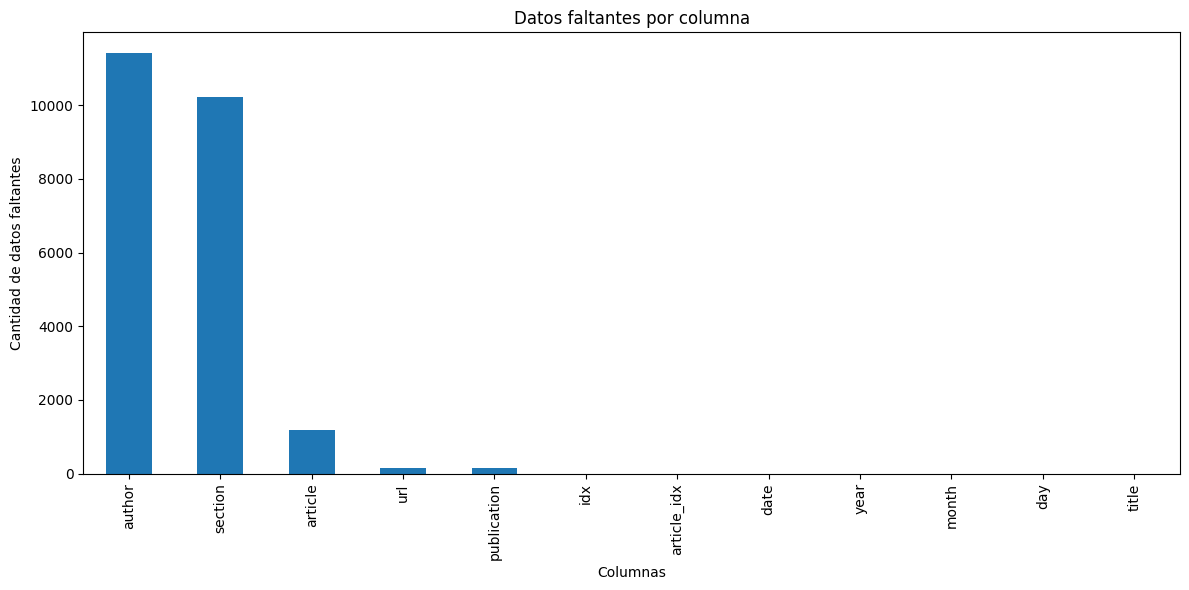

In [26]:

faltantes = df.isna().sum().sort_values(ascending=False)

faltantes.plot(kind="bar", figsize=(12,6))
plt.ylabel("Cantidad de datos faltantes")
plt.xlabel("Columnas")
plt.title("Datos faltantes por columna")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Conversión de tipo de datos

In [ ]:
# a fecha
df["date"] = pd.to_datetime(df["date"], format="mixed") # distintos formatos en las fechas
# a numérico
df["year"] = pd.to_numeric(df["year"], errors="coerce")
df["month"] = pd.to_numeric(df["month"], errors="coerce")
df["day"] = pd.to_numeric(df["day"], errors="coerce")
# a texto
text_columns = [
    "author",
    "title",
    "article",
    "url",
    "section",
    "publication"
]

df[text_columns] = df[text_columns].astype("string")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30213 entries, 0 to 30212
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   idx          30213 non-null  int64         
 1   article_idx  30213 non-null  int64         
 2   date         30213 non-null  datetime64[ns]
 3   year         30213 non-null  int64         
 4   month        30213 non-null  float64       
 5   day          30213 non-null  int64         
 6   author       18808 non-null  string        
 7   title        30213 non-null  string        
 8   article      29037 non-null  string        
 9   url          30072 non-null  string        
 10  section      19981 non-null  string        
 11  publication  30072 non-null  string        
dtypes: datetime64[ns](1), float64(1), int64(4), string(6)
memory usage: 2.8 MB


In [29]:
# TODO: Analice la cantidad de artículos por medio de prensa

# Tome los 5 medios con más artículos
top_5_publications = df["publication"].value_counts().head(5).reset_index() # ya lo devuelve descendiente, en un dataframe
top_5_publications.columns = [
    "Medio de prensa",
    "Cantidad de artículos"]
top_5_publications

,Medio de prensa,Cantidad de artículos
0,Reuters,9431
1,The New York Times,2840
2,CNBC,2623
3,The Hill,2349
4,People,1528


In [43]:
df_top_5 = df[df["publication"].isin(top_5_publications["Medio de prensa"])]

## B. Visualización temporal
Genere una gráfica que permita visualizar los artículos de los cinco medios a lo largo del tiempo, con alguna escala temporal adecuada. \
Comente si se identifican momentos de mayor actividad o patrones temporales en la cobertura.

/var/folders/41/jkqbp04530d7853fv_5s0p580000gp/T/ipykernel_1145/2631245403.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_top_5["año_mes"] = df_top_5["date"].dt.to_period("M") # si lo dejo por fecha con día, queda muy ruidoso


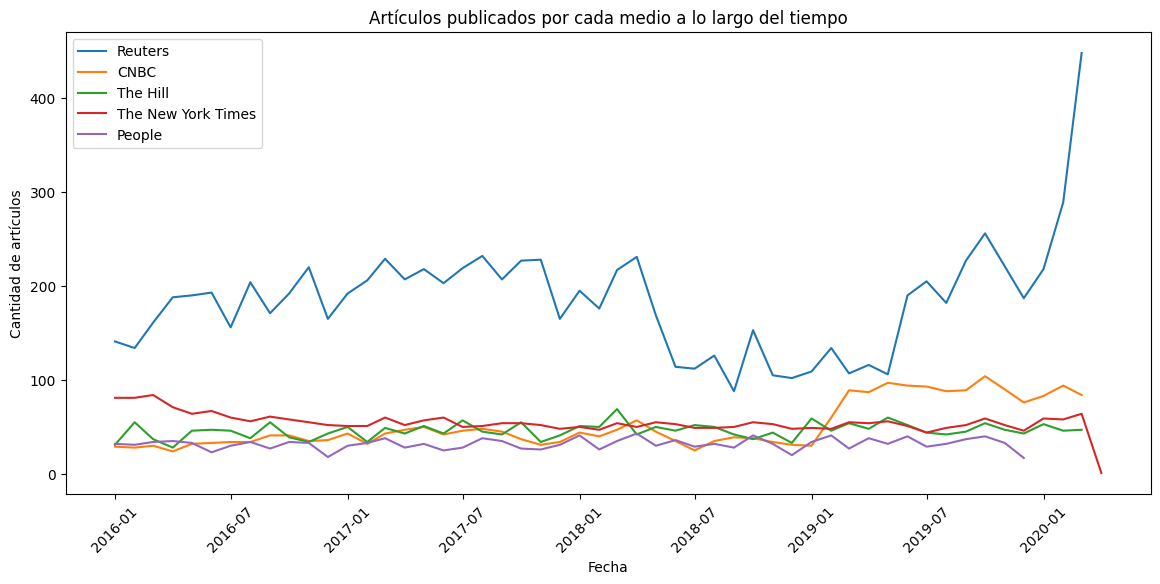

In [ ]:
# TODO: Visualización de los artículos de cada medio a lo largo del tiempo
# Preste especial atención al formato de la columna 'date', ya que puede contener diferentes formatos de fecha.

df_top_5["año_mes"] = df_top_5["date"].dt.to_period("M") # si lo dejo por fecha con día, queda muy ruidoso
articulos_por_fecha = (df_top_5
    .groupby(["año_mes", "publication"])
    .size()
    .reset_index(name="Cantidad"))

plt.figure(figsize=(14,6))
for publication in df_top_5["publication"].dropna().unique(): #por si hay NAs
    
    subset = articulos_por_fecha[
        articulos_por_fecha["publication"] == publication
    ]
    
    plt.plot(
        subset["año_mes"].dt.to_timestamp(),
        subset["Cantidad"],
        label=publication
    )

plt.xlabel("Fecha")
plt.ylabel("Cantidad de artículos")
plt.title("Artículos publicados por cada medio a lo largo del tiempo")
plt.legend()
plt.xticks(rotation=45)

plt.show()

Reuters es el medio con la mayor cantidad de artículos publicados para todo el período (2016 a 2020). En general cuenta con entre 100 y 250 artículos por mes en casi todo el período, excepto en 2020, donde se ve un crecimiento en las publicaciones que duplican las cifras anteriores.

El resto de medios mantuvo cantidades similares entre sí para todo el período, con valores en general en el entorno de 50 y no mayores a 100. Particularmente, CNBC muestra un aumento en sus publicaciónes luego de comenzado el 2019, con valores alrededor de 100 hasta el final del período.

## C. Limpieza de texto y conteo de palabras
Se provee la función `clean_text(...)` que realiza parte de la normalización del texto. \
**Complete la función** agregando signos de puntuación faltantes y cualquier otra normalización que considere oportuna. \
Compruebe el resultado observando el contenido del DataFrame procesado. Comente todas las transformaciones que haya agregado y justifique.

In [ ]:
def clean_text(df, column_name):

    # Eliminar primeras palabras hasta el primer "\n"
    result = df[column_name].str.replace(r"^[^\n]*\n", "", regex=True)

    # Convertir todo a minúsculas
    result = result.str.lower()

    # TODO: completar signos de puntuación faltantes
    for punc in ["[", "\n", ",", ":", "?"]:
        result = result.str.replace(punc, " ")

    return result

In [ ]:
# TODO: Aplique clean_text sobre la columna de texto elegida y cree una nueva columna "CleanText"



## D. Elección de campos de texto
Discuta si conviene trabajar con:
- sólo el cuerpo del artículo,
- sólo el título,
- o una combinación de ambos.

Justifique brevemente su decisión.

*TODO: Escriba su análisis en el informe.*

## E. Pistas que identifican al medio de prensa
Analice si en el texto aparecen pistas que identifiquen de manera directa al medio de prensa (nombres del medio, URLs, firmas, nombres de secciones, plantillas repetidas, etc.). \
En caso de encontrarlas, comente si considera conveniente eliminarlas o reducir su impacto, y justifique su decisión.

In [ ]:
# TODO: Explore el texto buscando pistas que identifiquen directamente al medio de prensa
# Por ejemplo, busque nombres de medios, URLs, firmas, etc.

## F. Restricción por sección o período temporal
Evalúe si conviene restringir el análisis a artículos de una misma sección temática o de un período temporal acotado, con el objetivo de reducir el efecto del tema sobre una futura tarea de clasificación por medio. \
No es necesario implementar esta restricción, pero sí discutir sus posibles ventajas y desventajas.

*TODO: Escriba su análisis en el informe.*

# Parte 2: Conteo de Palabras y Visualizaciones

## A. Palabras más frecuentes por medio
Realice una visualización que permita comparar las palabras más frecuentes de cada uno de los cinco medios de prensa. \
Sin necesidad de implementarlo, proponga ideas para modificar esta visualización con el fin de encontrar diferencias entre secciones temáticas, fechas, o tipos de noticias.

In [ ]:
# TODO: Realice una visualización que permita comparar las palabras más frecuentes
# de cada uno de los cinco medios de prensa.
# - ¿Encuentra algún problema en los resultados?


## B. Medios con mayor cantidad de palabras
Corra el código que permite encontrar los medios con mayor cantidad de palabras. \
En caso de encontrar algún problema luego de realizar la visualización, comente a qué se debe y proponga formas de resolverlo.

In [ ]:
# TODO: Busque los medios con mayor cantidad de palabras

## C. Matriz de menciones entre medios
Construya una matriz de 5×5, donde cada fila y columna corresponden a un medio de prensa, y la entrada (i,j) contiene la cantidad de veces que el medio *i* menciona al medio *j*. \
\
**Opcional:** genere un grafo dirigido con esa matriz de adyacencia para visualizar las menciones. Puede ser útil la biblioteca `networkx`.

In [ ]:
# TODO: Construya una matriz de 5x5, donde cada fila y columna corresponden a un medio de prensa,
# y la entrada (i,j) contiene la cantidad de veces que el medio "i" menciona al medio "j".

# mentions_matrix = ...


In [ ]:
# Opcional: Genere un grafo dirigido con la matriz de adyacencia para visualizar las menciones.
# Puede ser útil la biblioteca networkx.



## D. Preguntas propuestas
Proponga al menos tres preguntas que se podrían intentar responder a partir de estos datos, y mencione posibles caminos para responderlas, sin implementar nada.

*TODO: Escriba sus preguntas y posibles caminos en el informe.*